In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

In [2]:
#Load cleaned datasets
ft = pd.read_csv('fulltime_clean.csv')
pt = pd.read_csv('parttime_clean.csv')

# Define outcome and drop non-predictors
target_ft = 'retention_fulltime'
target_pt = 'retention_parttime'

drop_cols_ft = ['unit_id', target_ft]
drop_cols_pt = ['unit_id', target_pt]

X_ft = ft.drop(columns=drop_cols_ft)
y_ft = ft[target_ft]

X_pt = pt.drop(columns=drop_cols_pt)
y_pt = pt[target_pt]

# Train/test split (80/20)
X_ft_train, X_ft_test, y_ft_train, y_ft_test = train_test_split(X_ft, y_ft, test_size=0.2, random_state=42)
X_pt_train, X_pt_test, y_pt_train, y_pt_test = train_test_split(X_pt, y_pt, test_size=0.2, random_state=42)

In [3]:
# Define columns to scale
scale_cols_ft = ['student_faculty_ratio', 'applicants', 'admitted', 'enrolled_total', 'enrolled_fulltime',
                 'sat_submission_pct', 'act_submission_pct', 'disability_pct', 'pell_grant_pct', 
                 'pell_grant_avg', 'institutional_grant_pct', 'institutional_grant_avg', 'loan_pct', 
                 'loan_avg', 'any_aid_pct', 'tuition_fees', 'coa_instate_oncampus', 'coa_outofstate_oncampus']

scale_cols_pt = ['student_faculty_ratio', 'applicants', 'admitted', 'enrolled_total', 'enrolled_parttime',
                 'sat_submission_pct', 'act_submission_pct', 'disability_pct', 'pell_grant_pct', 
                 'pell_grant_avg', 'institutional_grant_pct', 'institutional_grant_avg', 'loan_pct', 
                 'loan_avg', 'any_aid_pct', 'tuition_fees', 'coa_instate_oncampus', 'coa_outofstate_oncampus']

# Fit scaler on training data, then transform both train and test
scaler_ft = StandardScaler()
scaler_pt = StandardScaler()

X_ft_train[scale_cols_ft] = scaler_ft.fit_transform(X_ft_train[scale_cols_ft])
X_ft_test[scale_cols_ft] = scaler_ft.transform(X_ft_test[scale_cols_ft])

X_pt_train[scale_cols_pt] = scaler_pt.fit_transform(X_pt_train[scale_cols_pt])
X_pt_test[scale_cols_pt] = scaler_pt.transform(X_pt_test[scale_cols_pt])

In [4]:
# Add constant for intercept
X_ft_train_sm = sm.add_constant(X_ft_train)
X_pt_train_sm = sm.add_constant(X_pt_train)

# Fit models
model_ft = sm.OLS(y_ft_train, X_ft_train_sm).fit()
model_pt = sm.OLS(y_pt_train, X_pt_train_sm).fit()

# View summaries
print(model_ft.summary())
print(model_pt.summary())

                            OLS Regression Results                            
Dep. Variable:     retention_fulltime   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     36.26
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          2.84e-121
Time:                        15:36:46   Log-Likelihood:                -4824.5
No. Observations:                1273   AIC:                             9697.
Df Residuals:                    1249   BIC:                             9821.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [ ]:
# Calculate VIF for each feature

from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

print("Full-time VIF:")
print(calc_vif(X_ft_train))
print("\nPart-time VIF:")
print(calc_vif(X_pt_train))

Full-time VIF:
                    feature        VIF
7     religious_affiliation        inf
23                control_4        inf
20     coa_instate_oncampus  49.555434
19             tuition_fees  32.085985
4         enrolled_fulltime  25.272872
21  coa_outofstate_oncampus  21.545587
3            enrolled_total  21.373827
15  institutional_grant_avg   8.875510
2                  admitted   6.853382
1                applicants   4.958040
8              study_abroad   4.623379
14  institutional_grant_pct   3.251195
18              any_aid_pct   3.220286
22                control_3   2.604476
12           pell_grant_pct   2.402879
10       undergrad_research   2.140122
9           evening_weekend   2.087610
16                 loan_pct   1.640604
11           disability_pct   1.606314
0     student_faculty_ratio   1.565572
17                 loan_avg   1.454272
5        sat_submission_pct   1.223921
13           pell_grant_avg   1.218688
6        act_submission_pct   1.205390

Part-time

C:\Users\Keith\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\Keith\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [ ]:
# Determine if religious affiliation is any different from control 4

print(pd.crosstab(ft['religious_affiliation'], ft['control_4']))
print(pd.crosstab(pt['religious_affiliation'], pt['control_4']))

control_4                0    1
religious_affiliation          
0                      995    0
1                        0  597
control_4                0    1
religious_affiliation          
0                      696    0
1                        0  334


In [ ]:
# Check VIF after dropping religious affiliation and cost of attendance features

drop_features = ['religious_affiliation', 'coa_instate_oncampus', 'coa_outofstate_oncampus', 'enrolled_total']

X_ft_train_v2 = X_ft_train.drop(columns=drop_features)
X_ft_test_v2 = X_ft_test.drop(columns=drop_features)

X_pt_train_v2 = X_pt_train.drop(columns=drop_features)
X_pt_test_v2 = X_pt_test.drop(columns=drop_features)

print("Full-time VIF v2:")
print(calc_vif(X_ft_train_v2))
print("\nPart-time VIF v2:")
print(calc_vif(X_pt_train_v2))

Full-time VIF v2:
                    feature        VIF
17             tuition_fees  10.969171
13  institutional_grant_avg   8.828897
3         enrolled_fulltime   7.620649
2                  admitted   6.540610
1                applicants   4.863753
6              study_abroad   4.229266
16              any_aid_pct   3.172645
12  institutional_grant_pct   2.988900
19                control_4   2.632311
10           pell_grant_pct   2.369524
18                control_3   2.315658
8        undergrad_research   2.128022
7           evening_weekend   2.056645
14                 loan_pct   1.638184
9            disability_pct   1.596812
0     student_faculty_ratio   1.543556
15                 loan_avg   1.450982
4        sat_submission_pct   1.219924
11           pell_grant_avg   1.207745
5        act_submission_pct   1.178107

Part-time VIF v2:
                    feature        VIF
17             tuition_fees  12.155286
13  institutional_grant_avg   8.892532
6              study_abroad

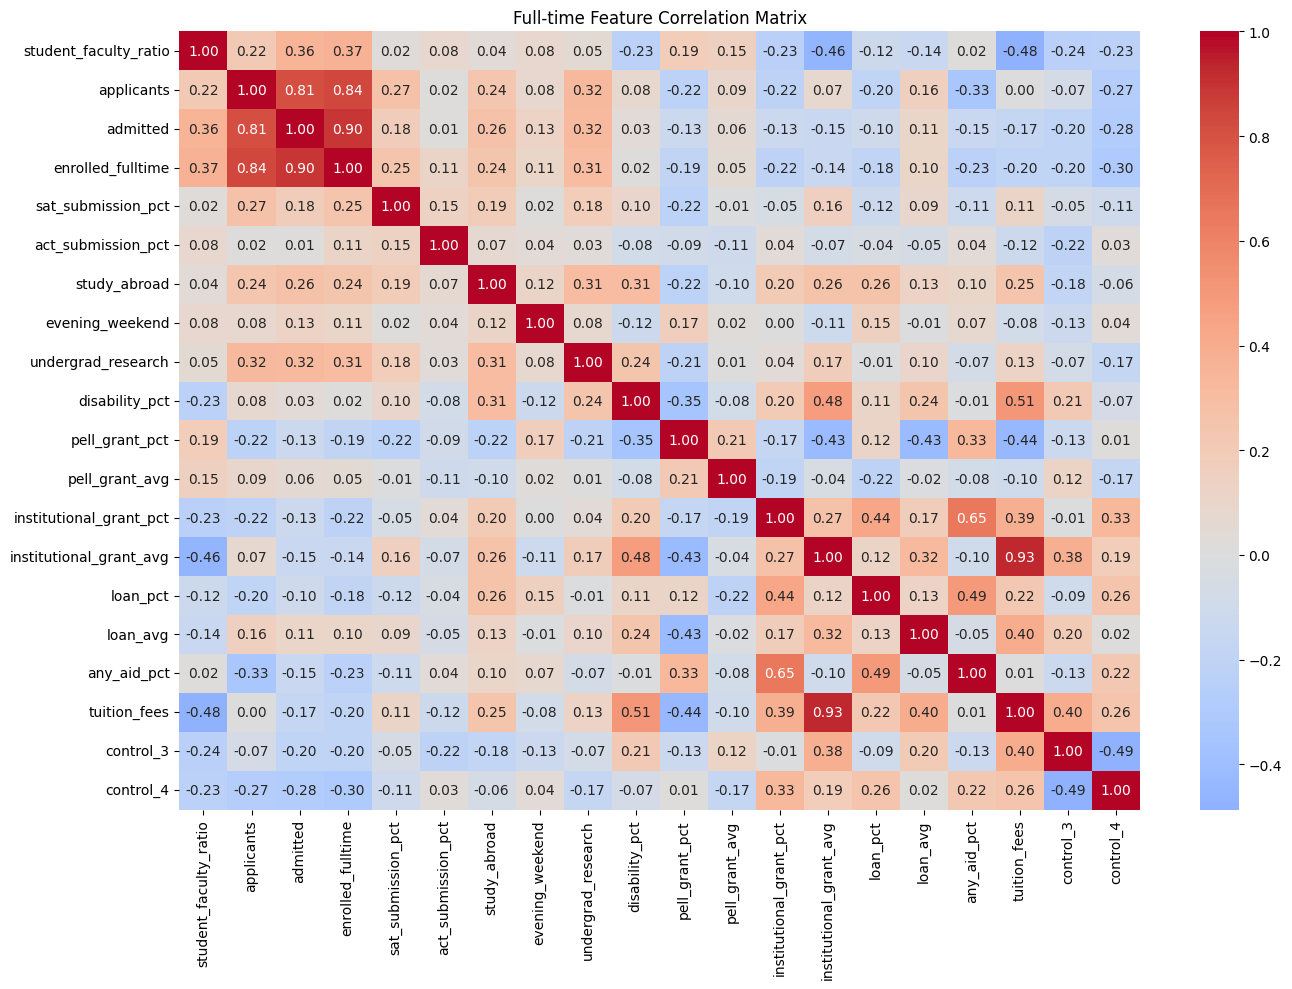

In [ ]:
# Create correlation matrix heatmap for full-time features

import matplotlib.pyplot as plt
import seaborn as sns

corr = X_ft_train_v2.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Full-time Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Check VIF after dropping tuition fees

drop_features_v2 = ['religious_affiliation', 'coa_instate_oncampus', 'coa_outofstate_oncampus', 'enrolled_total', 'tuition_fees']

X_ft_train_v3 = X_ft_train.drop(columns=drop_features_v2)
X_ft_test_v3 = X_ft_test.drop(columns=drop_features_v2)

X_pt_train_v3 = X_pt_train.drop(columns=drop_features_v2)
X_pt_test_v3 = X_pt_test.drop(columns=drop_features_v2)

print("Full-time VIF v3:")
print(calc_vif(X_ft_train_v3))
print("\nPart-time VIF v3:")
print(calc_vif(X_pt_train_v3))

Full-time VIF v3:
                    feature       VIF
3         enrolled_fulltime  7.527506
2                  admitted  6.444167
1                applicants  4.863727
6              study_abroad  4.078617
16              any_aid_pct  3.171123
12  institutional_grant_pct  2.920801
18                control_4  2.464795
13  institutional_grant_avg  2.363430
10           pell_grant_pct  2.346715
17                control_3  2.166808
8        undergrad_research  2.112163
7           evening_weekend  2.051992
14                 loan_pct  1.608465
0     student_faculty_ratio  1.543248
9            disability_pct  1.512130
15                 loan_avg  1.385563
4        sat_submission_pct  1.217281
11           pell_grant_avg  1.200847
5        act_submission_pct  1.167461

Part-time VIF v3:
                    feature       VIF
2                  admitted  3.962199
6              study_abroad  3.856211
1                applicants  3.796066
16              any_aid_pct  3.021884
12  instituti

In [ ]:
# New model
# Add constant for intercept
X_ft_train_v3_sm = sm.add_constant(X_ft_train_v3)
X_pt_train_v3_sm = sm.add_constant(X_pt_train_v3)

# Fit models
model_ft_v2 = sm.OLS(y_ft_train, X_ft_train_v3_sm).fit()
model_pt_v2 = sm.OLS(y_pt_train, X_pt_train_v3_sm).fit()

# View summaries
print(model_ft_v2.summary())
print(model_pt_v2.summary())

                            OLS Regression Results                            
Dep. Variable:     retention_fulltime   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     43.39
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          5.63e-123
Time:                        15:36:48   Log-Likelihood:                -4828.2
No. Observations:                1273   AIC:                             9696.
Df Residuals:                    1253   BIC:                             9799.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [ ]:
# Relax significance threshold to p < 0.10 and refit models
# Significant predictors at p < 0.10
keep_ft = ['student_faculty_ratio', 'applicants', 'enrolled_fulltime', 'sat_submission_pct',
           'disability_pct', 'pell_grant_pct', 'pell_grant_avg', 'institutional_grant_pct',
           'institutional_grant_avg', 'loan_pct', 'loan_avg', 'any_aid_pct', 'evening_weekend']

keep_pt = ['applicants', 'admitted', 'act_submission_pct', 'pell_grant_pct',
           'institutional_grant_pct', 'loan_pct', 'any_aid_pct']

X_ft_train_v4 = X_ft_train_v3[keep_ft]
X_ft_test_v4 = X_ft_test_v3[keep_ft]

X_pt_train_v4 = X_pt_train_v3[keep_pt]
X_pt_test_v4 = X_pt_test_v3[keep_pt]

# Refit models
X_ft_train_v4_sm = sm.add_constant(X_ft_train_v4)
X_pt_train_v4_sm = sm.add_constant(X_pt_train_v4)

model_ft_v3 = sm.OLS(y_ft_train, X_ft_train_v4_sm).fit()
model_pt_v3 = sm.OLS(y_pt_train, X_pt_train_v4_sm).fit()

print(model_ft_v3.summary())
print(model_pt_v3.summary())

                            OLS Regression Results                            
Dep. Variable:     retention_fulltime   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     63.14
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          3.13e-127
Time:                        15:36:48   Log-Likelihood:                -4830.5
No. Observations:                1273   AIC:                             9689.
Df Residuals:                    1259   BIC:                             9761.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [ ]:
# Find R² and RMSE for test data

from sklearn.linear_model import LinearRegression

# Fit sklearn models on training data
lr_ft = LinearRegression()
lr_pt = LinearRegression()

lr_ft.fit(X_ft_train_v4, y_ft_train)
lr_pt.fit(X_pt_train_v4, y_pt_train)

# Predict on test data
y_ft_pred = lr_ft.predict(X_ft_test_v4)
y_pt_pred = lr_pt.predict(X_pt_test_v4)

# Evaluate
print("Full-time model:")
print(f"  R² (test):  {r2_score(y_ft_test, y_ft_pred):.3f}")
print(f"  RMSE (test): {np.sqrt(mean_squared_error(y_ft_test, y_ft_pred)):.3f}")

print("\nPart-time model:")
print(f"  R² (test):  {r2_score(y_pt_test, y_pt_pred):.3f}")
print(f"  RMSE (test): {np.sqrt(mean_squared_error(y_pt_test, y_pt_pred)):.3f}")

Full-time model:
  R² (test):  0.413
  RMSE (test): 9.153

Part-time model:
  R² (test):  -0.001
  RMSE (test): 31.483


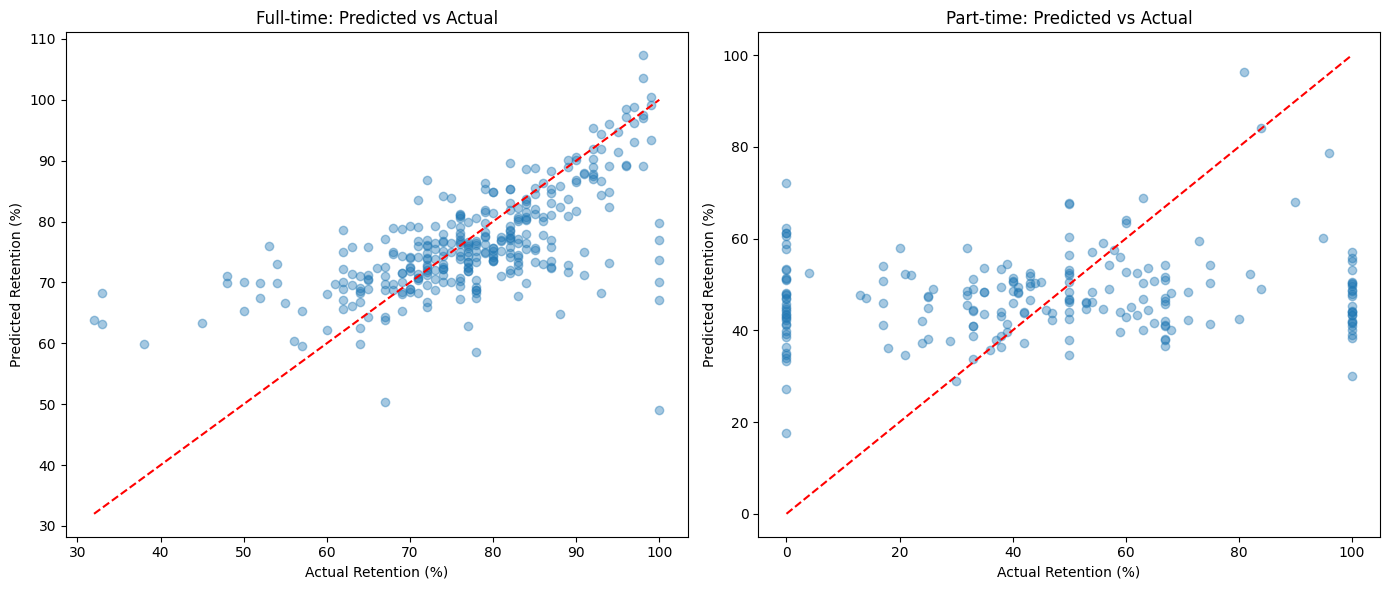

In [ ]:
# Find residuals for test data

import matplotlib.pyplot as plt

# Full-time predictions on test set
# Part-time predictions on test set

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicted vs Actual
axes[0].scatter(y_ft_test, y_ft_pred, alpha=0.4)
axes[0].plot([y_ft_test.min(), y_ft_test.max()], [y_ft_test.min(), y_ft_test.max()], 'r--')
axes[0].set_xlabel('Actual Retention (%)')
axes[0].set_ylabel('Predicted Retention (%)')
axes[0].set_title('Full-time: Predicted vs Actual')

axes[1].scatter(y_pt_test, y_pt_pred, alpha=0.4)
axes[1].plot([y_pt_test.min(), y_pt_test.max()], [y_pt_test.min(), y_pt_test.max()], 'r--')
axes[1].set_xlabel('Actual Retention (%)')
axes[1].set_ylabel('Predicted Retention (%)')
axes[1].set_title('Part-time: Predicted vs Actual')

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

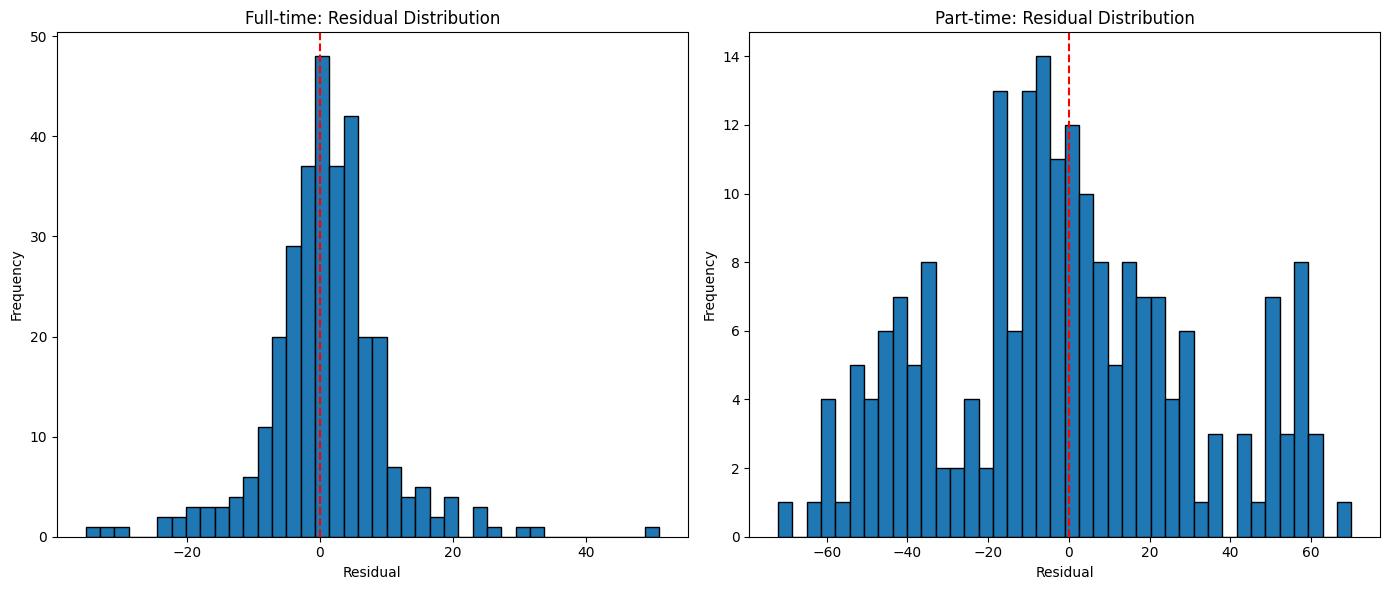

In [ ]:
# visualize residuals

ft_residuals = y_ft_test - y_ft_pred
pt_residuals = y_pt_test - y_pt_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(ft_residuals, bins=40, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Full-time: Residual Distribution')

axes[1].hist(pt_residuals, bins=40, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Part-time: Residual Distribution')

plt.tight_layout()
plt.savefig('residual_histograms.png', dpi=150)
plt.show()

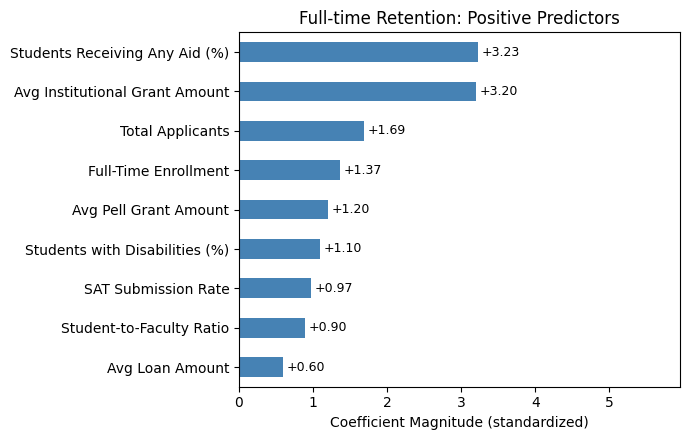

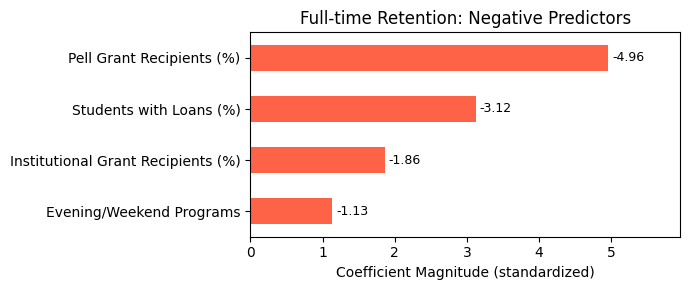

In [ ]:
# Visualize coefficients for full-time model

ft_coefs = pd.Series(model_ft_v3.params[1:], index=X_ft_train_v4.columns)

labels = {
    'pell_grant_pct': 'Pell Grant Recipients (%)',
    'loan_pct': 'Students with Loans (%)',
    'institutional_grant_pct': 'Institutional Grant Recipients (%)',
    'evening_weekend': 'Evening/Weekend Programs',
    'any_aid_pct': 'Students Receiving Any Aid (%)',
    'institutional_grant_avg': 'Avg Institutional Grant Amount',
    'applicants': 'Total Applicants',
    'enrolled_fulltime': 'Full-Time Enrollment',
    'pell_grant_avg': 'Avg Pell Grant Amount',
    'disability_pct': 'Students with Disabilities (%)',
    'sat_submission_pct': 'SAT Submission Rate',
    'student_faculty_ratio': 'Student-to-Faculty Ratio',
    'loan_avg': 'Avg Loan Amount',
}

ft_coefs = ft_coefs.rename(labels)

ft_pos = ft_coefs[ft_coefs > 0].abs().sort_values()
ft_neg = ft_coefs[ft_coefs < 0].abs().sort_values()

x_max = ft_coefs.abs().max() * 1.2

bar_height = 0.3  # height per bar in inches
padding = 1.8       # extra space for title, axis labels, etc.

fig, ax = plt.subplots(figsize=(7, len(ft_pos) * bar_height + padding))
ft_pos.plot(kind='barh', ax=ax, color='steelblue')
for i, val in enumerate(ft_pos):
    ax.text(val + 0.05, i, f'+{val:.2f}', va='center', fontsize=9)
ax.set_xlim(0, x_max)
ax.set_title('Full-time Retention: Positive Predictors')
ax.set_xlabel('Coefficient Magnitude (standardized)')
plt.tight_layout()
plt.savefig('coefficient_plots_ft_positive.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, len(ft_neg) * bar_height + padding))
ft_neg.plot(kind='barh', ax=ax, color='tomato')
for i, val in enumerate(ft_neg):
    ax.text(val + 0.05, i, f'-{val:.2f}', va='center', fontsize=9)
ax.set_xlim(0, x_max)
ax.set_title('Full-time Retention: Negative Predictors')
ax.set_xlabel('Coefficient Magnitude (standardized)')
plt.tight_layout()
plt.savefig('coefficient_plots_ft_negative.png', dpi=150)
plt.show()

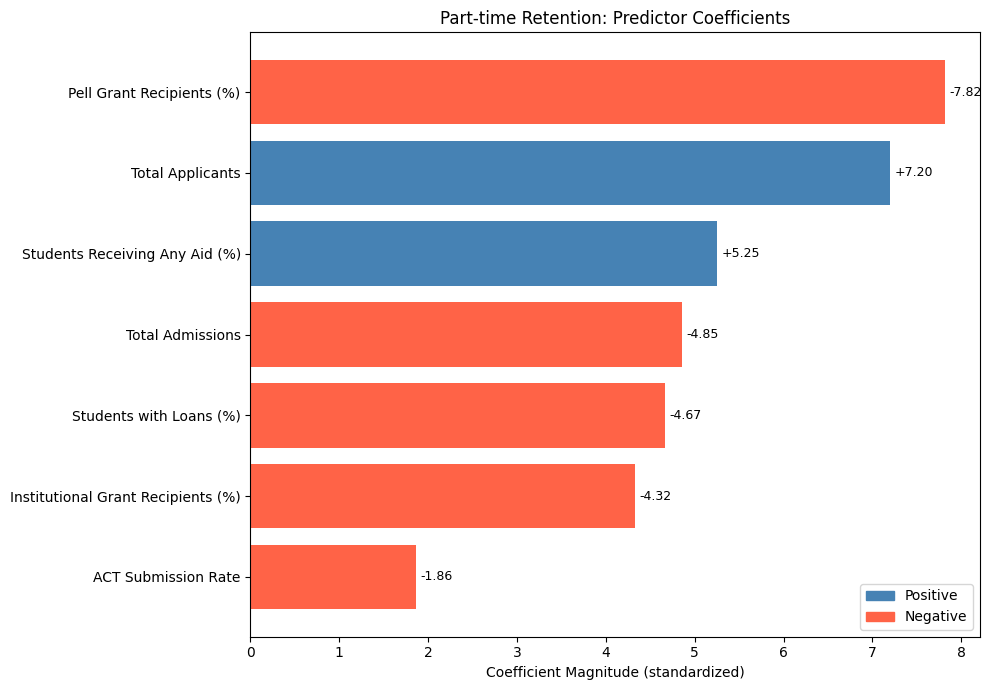

In [ ]:
# Visualize coefficients for part-time model

pt_coefs = pd.Series(model_pt_v3.params[1:], index=X_pt_train_v4.columns).sort_values()

labels_pt = {
    'pell_grant_pct': 'Pell Grant Recipients (%)',
    'admitted': 'Total Admissions',
    'loan_pct': 'Students with Loans (%)',
    'institutional_grant_pct': 'Institutional Grant Recipients (%)',
    'act_submission_pct': 'ACT Submission Rate',
    'applicants': 'Total Applicants',
    'any_aid_pct': 'Students Receiving Any Aid (%)',
}

pt_coefs = pt_coefs.rename(labels_pt)
pt_coefs_abs = pt_coefs.abs().sort_values()
pt_coefs_ordered = pt_coefs[pt_coefs_abs.index]

colors = ['tomato' if x < 0 else 'steelblue' for x in pt_coefs_ordered]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(pt_coefs_ordered.index, pt_coefs_ordered.abs(), color=colors)

for bar, val in zip(bars, pt_coefs_ordered):
    label = f'+{val:.2f}' if val > 0 else f'{val:.2f}'
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=9)

ax.set_xlabel('Coefficient Magnitude (standardized)')
ax.set_title('Part-time Retention: Predictor Coefficients')
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color='steelblue', label='Positive'),
    plt.Rectangle((0, 0), 1, 1, color='tomato', label='Negative')
], loc='lower right')

plt.tight_layout()
plt.savefig('coefficient_plots_pt.png', dpi=150)
plt.show()

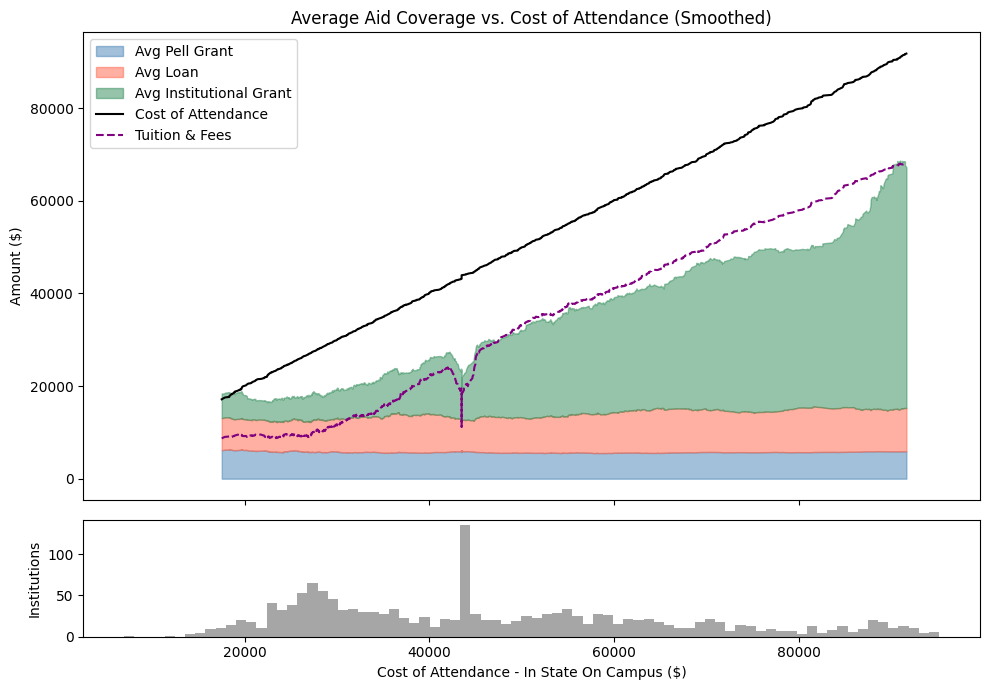

In [ ]:
# Slight non-sequiture: Aid coverage vs. cost of attendance

fig, (ax, ax_hist) = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [4, 1]}, sharex=True)

coa_sorted = ft[['coa_instate_oncampus', 'pell_grant_avg', 'loan_avg', 'institutional_grant_avg', 'tuition_fees']].dropna()
coa_sorted = coa_sorted.sort_values('coa_instate_oncampus').reset_index(drop=True)

window = 50
pell_smooth = coa_sorted['pell_grant_avg'].rolling(window, center=True).mean()
loan_smooth = coa_sorted['loan_avg'].rolling(window, center=True).mean()
inst_smooth = coa_sorted['institutional_grant_avg'].rolling(window, center=True).mean()
tuition_smooth = coa_sorted['tuition_fees'].rolling(window, center=True).mean()
coa_smooth = coa_sorted['coa_instate_oncampus'].rolling(window, center=True).mean()
coa_vals = coa_sorted['coa_instate_oncampus']

ax.fill_between(coa_vals, 0, pell_smooth, alpha=0.5, label='Avg Pell Grant', color='steelblue')
ax.fill_between(coa_vals, pell_smooth, pell_smooth + loan_smooth, alpha=0.5, label='Avg Loan', color='tomato')
ax.fill_between(coa_vals, pell_smooth + loan_smooth, pell_smooth + loan_smooth + inst_smooth, alpha=0.5, label='Avg Institutional Grant', color='seagreen')
ax.plot(coa_vals, coa_smooth, color='black', linewidth=1.5, label='Cost of Attendance')
ax.plot(coa_vals, tuition_smooth, color='purple', linewidth=1.5, linestyle='--', label='Tuition & Fees')

ax.set_ylabel('Amount ($)')
ax.set_title('Average Aid Coverage vs. Cost of Attendance (Smoothed)')
ax.legend()

ax_hist.hist(coa_sorted['coa_instate_oncampus'], bins=80, color='gray', alpha=0.7)
ax_hist.set_xlabel('Cost of Attendance - In State On Campus ($)')
ax_hist.set_ylabel('Institutions')

plt.tight_layout()
plt.savefig('aid_coverage_smooth.png', dpi=150)
plt.show()

In [ ]:
# Find median values for grants vs. cost of attendance

print(ft[['pell_grant_avg', 'loan_avg', 'institutional_grant_avg', 'tuition_fees', 'coa_instate_oncampus']].median().apply(lambda x: f"${x:,.2f}"))

pell_grant_avg              $5,759.00
loan_avg                    $7,519.50
institutional_grant_avg    $12,088.00
tuition_fees               $22,477.50
coa_instate_oncampus       $43,500.00
dtype: object


In [18]:
print(ft[['pell_grant_pct', 'institutional_grant_pct', 'loan_pct']].mean().apply(lambda x: f"{x:.1f}%"))

pell_grant_pct             40.4%
institutional_grant_pct    79.2%
loan_pct                   49.2%
dtype: object


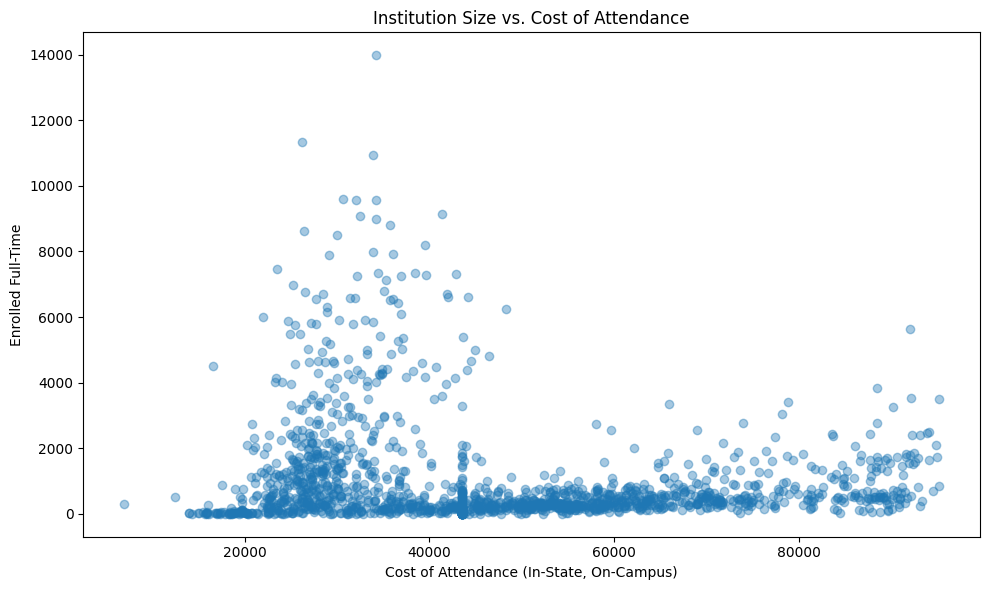

In [ ]:
# Plot institution size vs. cost of attendance

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(ft['coa_instate_oncampus'], ft['enrolled_fulltime'], alpha=0.4)
plt.xlabel('Cost of Attendance (In-State, On-Campus)')
plt.ylabel('Enrolled Full-Time')
plt.title('Institution Size vs. Cost of Attendance')
plt.tight_layout()
plt.show()